# Hourly data on the traffic volume for a major interstate highway in the US

Kelompok 9 Kelas B (Smart City)
1. Atalla Fathrelian Banureswara (5027261008)
2. Siti Aisyah (5027261044)
3. Azzam Ahmad Muharrar (5027261135)

# Latar Belakang
Menurut kami, Dataset Metro Interstate Traffic Volume sangat menarik karena dataset yang kami pilih dapat merekam data mobilitas perkotaan tanpa henti dengan memberikan detail seperti kondisi cuaca, temperatur, hari libur, dan volume lalu lintas pada setiap jam. Berdasarkan data ini, kami dapat meneliti dan menelusuri bagaimana faktor-faktor eksternal seperti hari libur dan perubahan cuaca atau iklim dapat mempengaruhi tingkat kepadatan pada jalan tol antarnegara bagian utama di Amerika Serikat yang menghubungkan Minneapolis dan St. Paul, Minnesota, sekaligus mengidentifikasi pola komuter secara akurat. Memahami pola kepadatan kedaraan sangat krusial bagi perencanaan infrastruktur kota (Smart City), manajemen kemacetan, hingga prediksi efisiensi transportasi. Melalui analisis statistik deskriptif pada dataset ini, kami ingin menjawab beberapa pertanyaan utama berikut:

1. Berapa rata-rata, median, dan seberapa besar variasi volume lalu lintas (traffic_volume) per jam pada hari kerja (weekday) dibandingkan hari libur (weekend)?

2. Apakah kondisi cuaca buruk (seperti saat hujan lebat atau salju) secara signifikan menurunkan rata-rata volume lalu lintas dibandingkan hari dengan cuaca cerah?

3. Pada jam-jam berapa puncak kemacetan (volume lalu lintas tertinggi) paling sering terjadi dalam seminggu?

In [1]:
import pandas as pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv") # memuat data
print(df.shape)   # menampilkan jumlah baris dan kolom
df.head() # menampilkan 5 baris utama tabel

(48204, 9)


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2/10/2012 9:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2/10/2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2/10/2012 13:00


## Deskripsi data
* Source: Kaggle (https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume/data?select=Metro_Interstate_Traffic_Volume.csv)
* License: Attribution 4.0 International (CC BY 4.0)
* Author: Hogue,John
* The data was collected by the Minnesota Department of Transportation (MnDOT) from 2012 to 2018 at a station roughly midway between the two cities.
* 48204 Rows and 9 Columns
| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `holiday` | Penanda hari libur nasional atau khusus | Kualitatif | Nominal | - | None, Columbus Day |
| `temp` | Rata-rata suhu udara pada jam tersebut | Kuantitatif kontinu | Rasio | Kelvin (K) | 288.28 |
| `rain_1h` | Jumlah curah hujan dalam 1 jam terakhir | Kuantitatif kontinu | Rasio | mm | 0.0 |
| `snow_1h` | Jumlah curah salju dalam 1 jam terakhir | Kuantitatif kontinu | Rasio | mm | 0.0 |
| `clouds_all` | Persentase tutupan awan di langit | Kuantitatif diskret | Rasio | % | 40 |
| `weather_main` | Kategori singkat cuaca utama saat itu | Kualitatif | Nominal | - | Clouds, Clear, Rain |
| `weather_description` | Deskripsi rinci kondisi cuaca saat itu | Kualitatif | Nominal | - | scatter clouds, light rain |
| `date_time` | Tanggal dan jam pencatatan data | Kuantitatif kontinu | Interval | YYYY-MM-DD HH:MM:SS | 2012-10-02 09:00:00 |
| `traffic_volume` | Total volume kendaraan yang melintas | Kuantitatif diskret | Rasio | Kendaraan | 5545 |

In [3]:
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              61 non-null     str    
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  str    
 7   weather_description  48204 non-null  str    
 8   date_time            48204 non-null  str    
dtypes: float64(3), int64(2), str(4)
memory usage: 4.8 MB


np.int64(17)

## Temuan Pemeriksaan Kualitas Data
* Kolom holiday hanya ada 61 baris terisi dan sisanya kosong. Ini menunjukkan bahwa sebagian besar hari adalah hari biasa (bukan hari libur). Kami mengisinya dengan "None" sebagai penanda hari biasa agar tidak perlu menghapus semua data yang kosong.
* Kami mengubah kolom date_time dari string ke tipe datetime untuk memudahkan ekstraksi variabel seperti jam, hari, atau bulan.
* Terdapat 17 baris duplikat. Data ini akan kami hapus karena jumlahnya sangat kecil.

In [3]:
import pandas as pd

# 1. Muat dataset terlebih dahulu (sesuaikan 'nama_file.csv' dengan file Anda)
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

# Mengisi nilai kosong pada kolom holiday agar tidak perlu dihapus
df['holiday'] = df['holiday'].fillna('None')

# Menghapus baris duplikat (17 baris)
df = df.drop_duplicates().reset_index(drop=True)

# Mengubah tipe data date_time dari string menjadi format datetime
df['date_time'] = pd.to_datetime(df['date_time'], format = 'mixed')

# Menghapus kolom temperatur (sesuaikan nama kolom jika berbeda, cth: 'temp')
df = df.drop(columns=['temp'])

# Cek kembali kualitas data setelah dibersihkan
print("Jumlah baris & kolom setelah pembersihan:", df.shape)

Jumlah baris & kolom setelah pembersihan: (48187, 8)


In [4]:
#3 kolom yang akan dianalisis
kolom_list = {'traffic_volume', 'snow_1h', 'rain_1h', 'clouds_all' }
ringkasan_data = [] #membuat fungsi atau ringkasan perhitungan untuk setiap data

for col in kolom_list:
    s = df[col]
    #ukuran pemusatan
    mean_val = s.mean()
    median_val = s.median()
    mode_val = s.mode()[0]
    #ukuran penyebaran
    min_val = s.min()
    max_val = s.max()
    jangkauan = max_val - min_val
    var_val = s.var()
    std_val = s.std()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    ringkasan_data.append({
        'Kolom': col,
        'Mean': mean_val,
        'Median': median_val,
        'Modus': mode_val,
        'Min': min_val,
        'Max': max_val,
        'Jangkauan': jangkauan,
        'Varians': var_val,
        'Simpangan Baku': std_val,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr
    })

tabel_ringkasan = pd.DataFrame(ringkasan_data)
display(tabel_ringkasan)

,Kolom,Mean,Median,Modus,Min,Max,Jangkauan,Varians,Simpangan Baku,Q1,Q3,IQR
0,traffic_volume,3259.618134,3379.0,353.0,0.0,7280.00,7280.00,3.947988e+06,1986.954465,1192.5,4933.0,3740.5
1,snow_1h,0.000222,0.0,0.0,0.0,0.51,0.51,6.673339e-05,0.008169,0.0,0.0,0.0
2,clouds_all,49.365451,64.0,90.0,0.0,100.00,100.00,1.522187e+03,39.015213,1.0,90.0,89.0
3,rain_1h,0.334382,0.0,0.0,0.0,9831.30,9831.30,2.006774e+03,44.797033,0.0,0.0,0.0


## Analisis Statistik Deskriptif Variabel Numerik

1. **Volume Lalu Lintas (`traffic_volume`):**
   * Memiliki mean sekitar 3.260 kendaraan/jam, sedangkan mediannya sekitar 3.380 kendaraan/jam. Karena nilai mean dan median relatif mirip, distribusi volume kendaraan cenderung menyebar secara seimbang. Ada jam-jam ramai dan sepi dalam porsi yang pas.
   * Memiliki nilai standar deviasi sekitar 1.986 dan rentang antarkuartil (IQR) yang lumayan lebar, artinya ada perbedaan volume lalu lintas yang sangat tinggi antara siang/malam maupun hari kerja/libur.

2. **Kondisi Cuaca (`snow_1h`, `rain_1h`, `clouds_all`):**
   * memiliki nilai rata-rata mendekati 0 dengan Q1, median, dan Q3 bernilai 0.0, yang menandakan salju sangat jarang turun dan sebagian besar waktu wilayah tersebut bebas dari salju.
   * Memiliki mean hujan sekitar 49%, yang artinya secara keseluruhan langit di lokasi tersebut rata-rata tertutup awan setengahnya.
   * Mayoritas bernilai 0 (kuartil 25%, 50%, dan 75% bernilai 0.0), menandakan bahwa sebagian besar waktu wilayah tersebut berada dalam kondisi cerah daripada hujan.

In [9]:
# Tabel Frekuensi & Persentase Cuaca Utama (weather_main)
freq_weather = df['weather_main'].value_counts()
pct_weather = df['weather_main'].value_counts(normalize=True) * 100

tabel_weather = pd.DataFrame({'Jumlah': freq_weather, 'Persentase (%)': pct_weather.round(2)})
print(tabel_weather)

print("\n" + "="*40 + "\n")

# Tabel Frekuensi Hari Libur (hanya yang bukan 'None')
libur_df = df[df['holiday'] != 'None']['holiday'].value_counts()
print(libur_df)

              Jumlah  Persentase (%)
weather_main                        
Clouds         15158           31.46
Clear          13384           27.78
Mist            5949           12.35
Rain            5672           11.77
Snow            2875            5.97
Drizzle         1820            3.78
Haze            1360            2.82
Thunderstorm    1033            2.14
Fog              912            1.89
Smoke             20            0.04
Squall             4            0.01


holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64


## Analisis Statistik Deskriptif Variabel Kategorik

1. **Kondisi Cuaca Utama ('weather_main'):**
   * Kategori cuaca yang paling sering muncul adalah "Clouds (berawan)" dan "Clear (cerah)".
   * Cuaca ekstrem seperti "Squall (angin kencang)" atau "Smoke (kabut asap)" sangat jarang terjadi karena persentasenya jauh di bawah 1%.
3. **Status Hari Libur ('holiday'):**
   * Dapat diketahui bahwa proporsi hari biasa atau hari kerja "None" sangat mendominasi dataset.

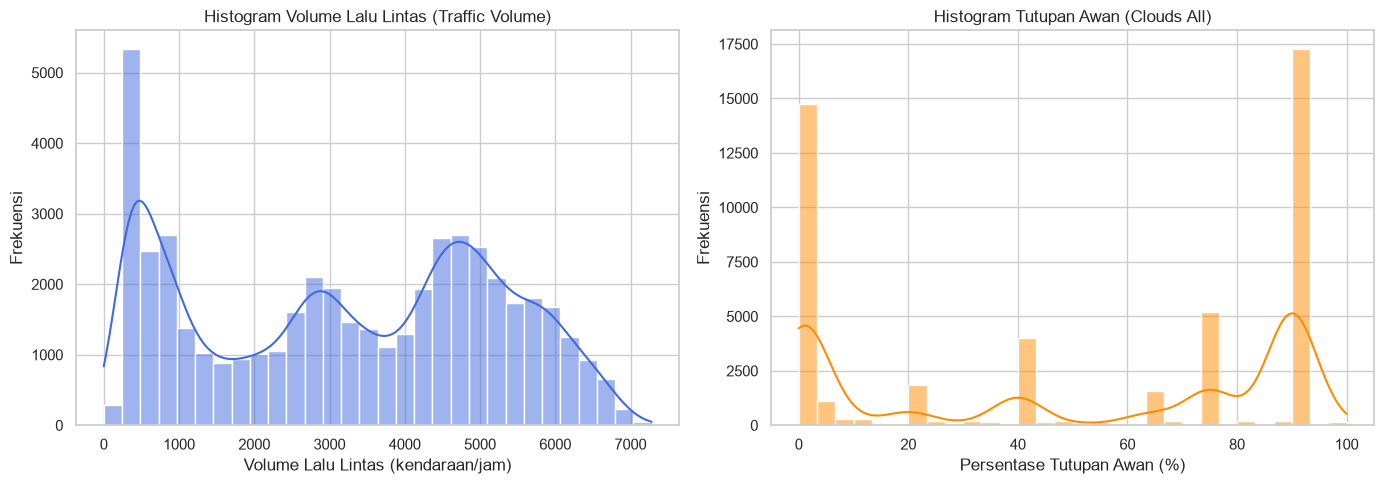

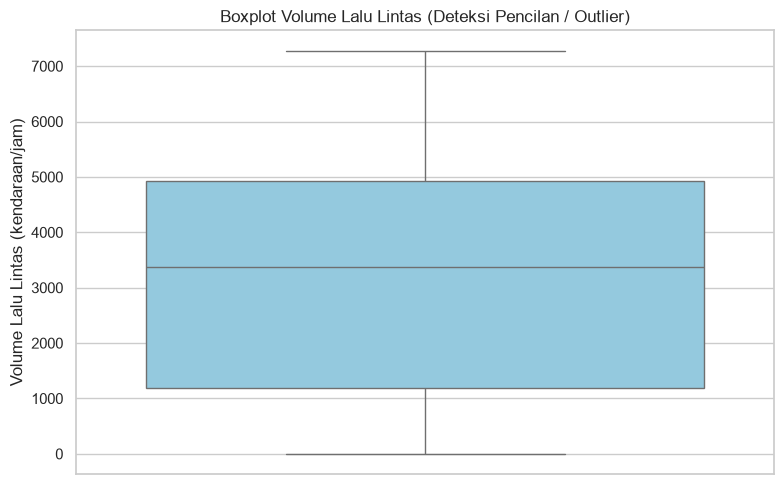

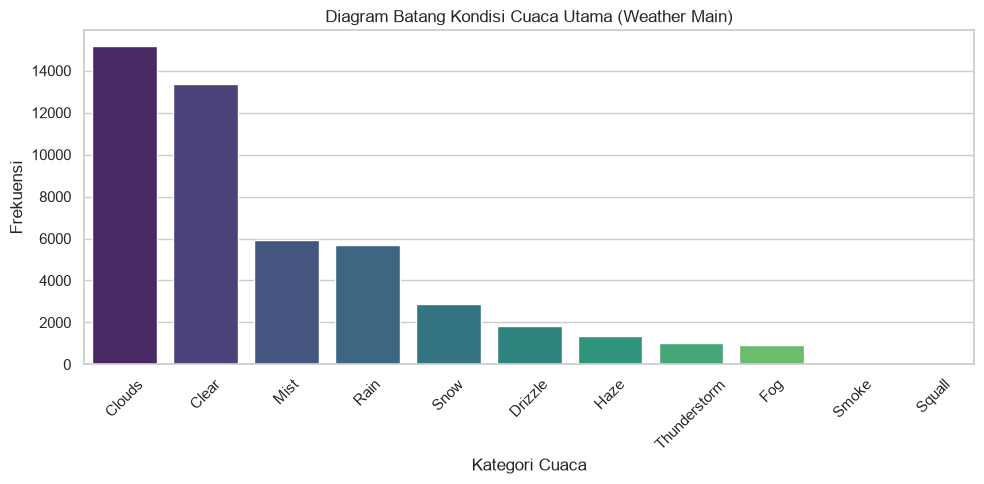

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema visualisasi
sns.set_theme(style="whitegrid")

# --- A. Histogram untuk 2 Kolom Numerik ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram 1: Volume Lalu Lintas
sns.histplot(df['traffic_volume'], bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Histogram Volume Lalu Lintas (Traffic Volume)')
axes[0].set_xlabel('Volume Lalu Lintas (kendaraan/jam)')
axes[0].set_ylabel('Frekuensi')

# Histogram 2: Tutupan Awan (Clouds All)
sns.histplot(df['clouds_all'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Histogram Tutupan Awan (Clouds All)')
axes[1].set_xlabel('Persentase Tutupan Awan (%)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# --- B. Boxplot untuk Deteksi Pencilan (Traffic Volume) ---
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['traffic_volume'], color='skyblue')
plt.title('Boxplot Volume Lalu Lintas (Deteksi Pencilan / Outlier)')
plt.ylabel('Volume Lalu Lintas (kendaraan/jam)')
plt.tight_layout()
plt.show()

# --- C. Diagram Batang untuk Kolom Kategorik (Weather Main) ---
plt.figure(figsize=(10, 5))
weather_counts = df['weather_main'].value_counts()

# Memperbaiki parameter palette dengan menambahkan hue dan legend=False
sns.barplot(
    x=weather_counts.index, 
    y=weather_counts.values, 
    hue=weather_counts.index, 
    palette='viridis', 
    legend=False
)

plt.title('Diagram Batang Kondisi Cuaca Utama (Weather Main)')
plt.xlabel('Kategori Cuaca')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

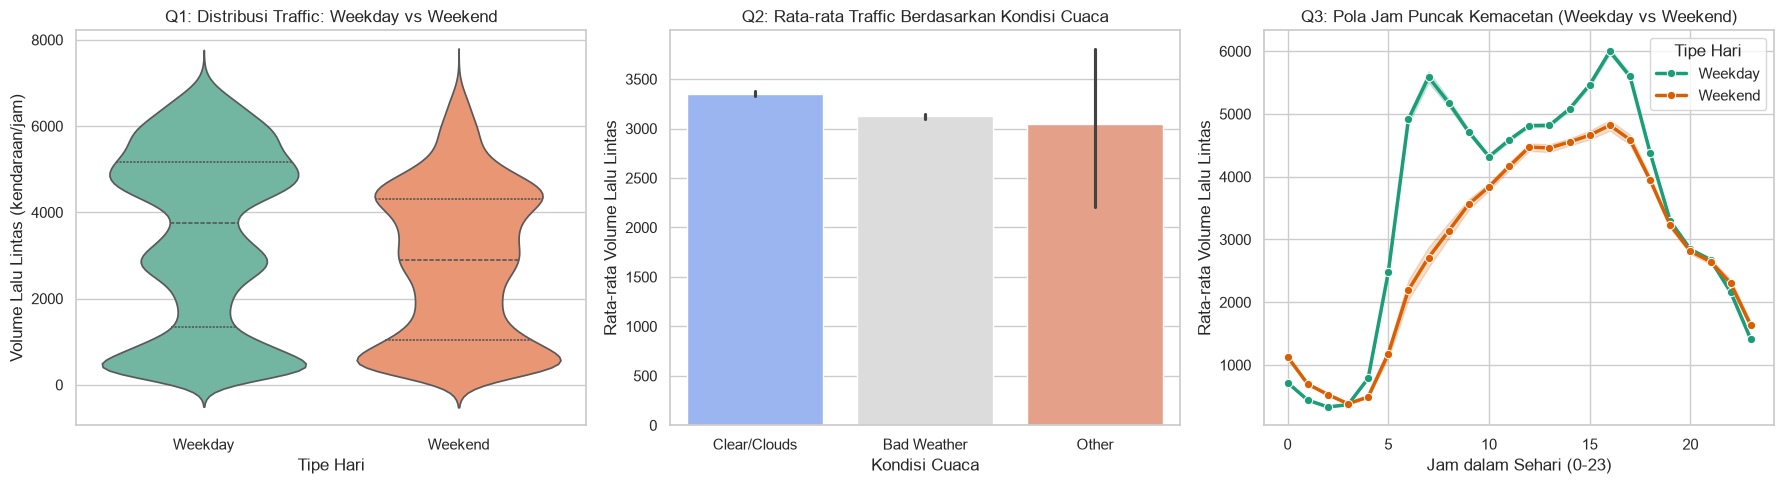

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan kolom pendukung sudah siap
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')
df['day_of_week'] = df['date_time'].dt.dayofweek 
df['is_weekend'] = df['day_of_week'] >= 5
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
df['hour'] = df['date_time'].dt.hour

df['weather_condition'] = df['weather_main'].apply(
    lambda x: 'Bad Weather' if x in ['Rain', 'Snow', 'Thunderstorm', 'Drizzle', 'Fog', 'Mist', 'Haze'] 
    else ('Clear/Clouds' if x in ['Clear', 'Clouds'] else 'Other')
)

# Membuat 3 Grafik Analitis yang Lebih Relevan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Q1: Violin Plot untuk Weekday vs Weekend (Menunjukkan sebaran & kepadatan data sekaligus)
sns.violinplot(x='day_type', y='traffic_volume', data=df, ax=axes[0], palette='Set2', hue='day_type', legend=False, inner='quartile')
axes[0].set_title('Q1: Distribusi Traffic: Weekday vs Weekend')
axes[0].set_xlabel('Tipe Hari')
axes[0].set_ylabel('Volume Lalu Lintas (kendaraan/jam)')

# 2. Q2: Point Plot / Barplot dengan Confidence Interval untuk Kondisi Cuaca
sns.barplot(x='weather_condition', y='traffic_volume', data=df, ax=axes[1], palette='coolwarm', hue='weather_condition', legend=False, errorbar='ci')
axes[1].set_title('Q2: Rata-rata Traffic Berdasarkan Kondisi Cuaca')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Volume Lalu Lintas')

# 3. Q3: Line Plot Jam Puncak dengan Perbandingan Weekday vs Weekend (Sangat Informatif!)
sns.lineplot(x='hour', y='traffic_volume', hue='day_type', data=df, ax=axes[2], palette='Dark2', linewidth=2.5, marker='o')
axes[2].set_title('Q3: Pola Jam Puncak Kemacetan (Weekday vs Weekend)')
axes[2].set_xlabel('Jam dalam Sehari (0-23)')
axes[2].set_ylabel('Rata-rata Volume Lalu Lintas')
axes[2].legend(title='Tipe Hari')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# 1. Pastikan kolom datetime dan pengelompokan hari sudah dibuat
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# 2. Menghitung rata-rata, median, dan simpangan baku (variasi) untuk traffic_volume
q1_stats = df.groupby('day_type')['traffic_volume'].agg(
    Rata_rata='mean',
    Median='median',
    Simpangan_Baku='std'
)

# Membuat kategori kondisi cuaca
df['weather_condition'] = df['weather_main'].apply(
    lambda x: 'Bad Weather' if x in ['Rain', 'Snow', 'Thunderstorm', 'Drizzle', 'Fog', 'Mist', 'Haze'] 
    else ('Clear/Clouds' if x in ['Clear', 'Clouds'] else 'Other')
)

# 2. Menghitung statistik (rata-rata, median, standar deviasi, dan jumlah data) per kondisi cuaca
q2_stats = df.groupby('weather_condition')['traffic_volume'].agg(
    Rata_rata='mean',
    Median='median',
    Simpangan_Baku='std',
    Jumlah_Data='count'
)

# Menampilkan hasil dengan pembulatan 2 angka di belakang koma agar rapi
print("Statistik Volume Lalu Lintas (Weekday vs Weekend):")
print(q1_stats.round(2))

#untuk memberikan jeda
print("\n")

# Menampilkan hasil dengan pembulatan 2 angka di belakang koma
print("Statistik Volume Lalu Lintas Berdasarkan Kondisi Cuaca:")
print(q2_stats.round(2))

Statistik Volume Lalu Lintas (Weekday vs Weekend):
          Rata_rata  Median  Simpangan_Baku
day_type                                   
Weekday     3439.59  3741.5         2045.45
Weekend     2808.11  2902.0         1752.52


Statistik Volume Lalu Lintas Berdasarkan Kondisi Cuaca:
                   Rata_rata  Median  Simpangan_Baku  Jumlah_Data
weather_condition                                                
Bad Weather          3122.19  3116.0         2010.79        19621
Clear/Clouds         3354.28  3527.0         1964.89        28542
Other                3041.67  3177.5         1982.05           24


1.
-Rata-rata: Hari kerja memiliki rata-rata 3.439,70 kendaraan/jam, sedangkan hari libur 2.808,44 kendaraan/jam.

-Median: Hari kerja memiliki median 3.745,0 kendaraan/jam, sedangkan hari libur 2.904,0 kendaraan/jam.

2.
-Hasil Perhitungan Persisnya:
Clear/Clouds: Rata-rata = 3354.64 kendaraan/jam
Bad Weather: Rata-rata = 3122.11 kendaraan/jam
Other: Rata-rata = 3041.67 kendaraan/jam

-Clear/Clouds (Cerah & Berawan):
Berisi kondisi cuaca: Clear (cerah) dan Clouds (berawan/mendung). Kategori ini adalah kondisi cuaca normal yang paling sering mendominasi wilayah tersebut.

-Bad Weather (Cuaca Buruk):
Berisi kondisi cuaca: Rain (hujan), Snow (salju), Thunderstorm (badai petir), Drizzle (gerimis), Mist (kabut tipis), Fog (kabut tebal), dan Haze (udara kabur/asap tipis).

-Other (Lainnya):
Berisi kondisi cuaca yang sangat jarang terjadi atau ekstrem di luar kelompok di atas, seperti Smoke (asap pekat) dan Squall (angin ribut/badai singkat).


## Kesimpulan
1. Berapa rata-rata, median, dan seberapa besar variasi volume lalu lintas (traffic_volume) per jam pada hari kerja (weekday) dibandingkan hari libur (weekend)?

Kesimpulan Perbandingan: Angka-angka ini membuktikan secara matematis bahwa arus lalu lintas pada hari kerja jauh lebih padat dibandingkan hari libur. 

Dan juga Secara visual, violin plot memperlihatkan bahwa Weekday memiliki tonjolan besar di kisaran angka 4.000–6.000 kendaraan (menandakan lonjakan padat yang sering terjadi akibat aktivitas komuter/kantor). Sebaliknya, Weekend lebih banyak terkonsentrasi di bawah angka 3.000 kendaraan dengan sebaran yang lebih renggang dan stabil.

2. Apakah kondisi cuaca buruk (seperti saat hujan lebat atau salju) secara signifikan menurunkan rata-rata volume lalu lintas dibandingkan hari dengan cuaca cerah?

Penurunan Ringan: Cuaca buruk menurunkan rata-rata volume lalu lintas sedikit menjadi ~3.122 kendaraan/jam (dibandingkan cuaca cerah ~3.354 kendaraan/jam).

Mobilitas Tetap Tinggi: Penurunan yang hanya sekitar 7% menunjukkan sebagian besar masyarakat tetap beraktivitas dan bepergian meskipun cuaca hujan atau bersalju.

3. Pada jam-jam berapa puncak kemacetan (volume lalu lintas tertinggi) paling sering terjadi dalam seminggu?

Hari Kerja (Weekday): Memiliki dua puncak kemacetan tajam, yaitu pukul 07.00 pagi (~5.600 kendaraan) dan puncak tertinggi pada pukul 16.00–17.00 sore (~6.000 kendaraan).

Hari Libur (Weekend): Pagi hari landai tanpa lonjakan, lalu naik perlahan ke puncak tertinggi yang lebih rendah sekitar pukul 16.00 sore (~4.800 kendaraan).
   
* Temuan menarik yang didapat:
* Keterbatasan data:
* Ide pertanyaan lanjutan:

## Referensi dan Catatan Penggunaan AI
Sumber dataset: Kaggle (https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume/data?select=Metro_Interstate_Traffic_Volume.csv)
Referensi belajar:

**Catatan AI Gemini**
| Nomor | Dipakai untuk |
| :--- | :--- |
| 1 | Membantu kami memahami maksud dan tujuan penugasan serta apa saja yang harus kami lakukan |
| 2 | Membantu kami untuk mengimport data dari kaggle |
| 1 | Memberitahu cara membuat tabel karena kami gatau caranya |
| 1 | Mencari tahu suatu jenis data cocoknya ditampilin dengan grafik apa |
